<h1>MOVIE RATING PREDICTION 
WITH PYTHON</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
imdb_df = pd.read_csv(r"C:\Users\Acer\Documents\Encryptix\Movie_Rating\IMDb Movies India.csv", encoding='unicode_escape')

**Rating Distribution**

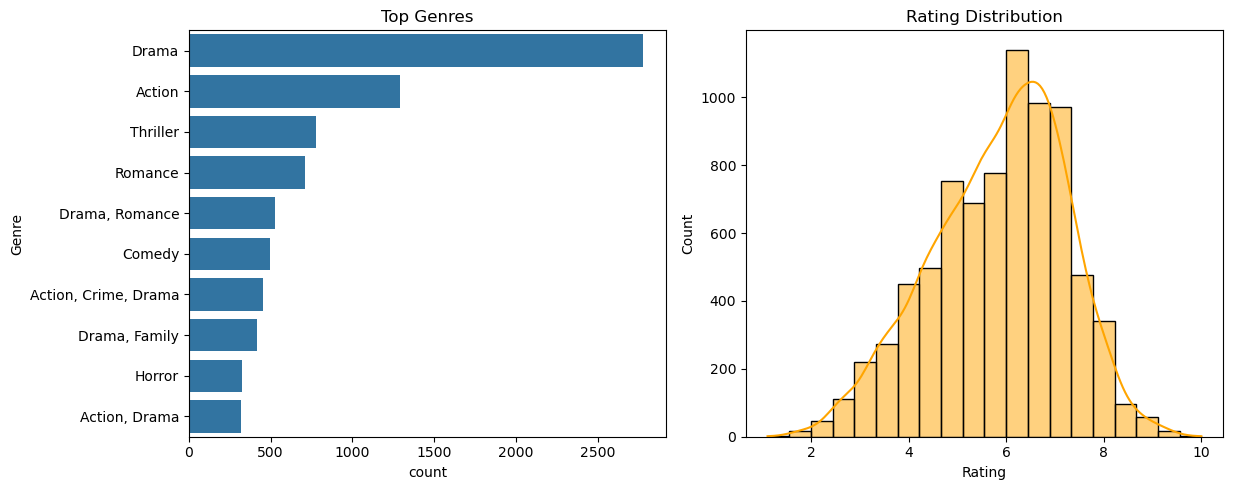

In [3]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=imdb_df, y='Genre', order=imdb_df['Genre'].value_counts().index[:10])
plt.title('Top Genres')

plt.subplot(1, 3, 2)
sns.histplot(imdb_df['Rating'], bins=20, kde=True, color='orange')
plt.title('Rating Distribution')

plt.tight_layout()
plt.show()

**Remove Unnecessary Data**

In [4]:
imdb_df.drop_duplicates(inplace=True)
imdb_df.dropna(inplace=True)

In [5]:
imdb_df['Year'] = imdb_df['Year'].str.replace(r'[()]', '', regex=True).astype(int)
imdb_df['Duration'] = pd.to_numeric(imdb_df['Duration'].str.replace(' min', ''))
imdb_df['Genre'] = imdb_df['Genre'].str.split(', ')
imdb_df = imdb_df.explode('Genre')
imdb_df['Votes'] = pd.to_numeric(imdb_df['Votes'].str.replace(',', ''))

In [6]:
imdb_df['Genre_mean_rating'] = imdb_df.groupby('Genre')['Rating'].transform('mean')
imdb_df['Director_encoded'] = imdb_df.groupby('Director')['Rating'].transform('mean')
imdb_df['Actor1_encoded'] = imdb_df.groupby('Actor 1')['Rating'].transform('mean')
imdb_df['Actor2_encoded'] = imdb_df.groupby('Actor 2')['Rating'].transform('mean')
imdb_df['Actor3_encoded'] = imdb_df.groupby('Actor 3')['Rating'].transform('mean')

In [7]:
imdb_df.drop(['Name'], axis=1, inplace=True)

<h2>Separate features</h2>

In [8]:
X = imdb_df[['Year', 'Votes', 'Duration', 'Genre_mean_rating', 'Director_encoded',
             'Actor1_encoded', 'Actor2_encoded', 'Actor3_encoded']]
y = imdb_df['Rating']

<h2>Model Training</h2>

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**LinearRegression**

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [11]:
y_pred = model.predict(X_test)

**Model Accuracy Evaluation**

In [15]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Predict on both train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [16]:
train_score = r2_score(y_train, y_train_pred)
test_score = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))


In [17]:
print(f"Training Accuracy: {train_score:.3f}")
print(f"Testing Accuracy : {test_score:.3f}")
print(f"Test RMSE: {rmse_test:.3f}")

Training Accuracy: 0.771
Testing Accuracy : 0.764
Test RMSE: 0.668


**Actual vs Predicted Movie Ratings**

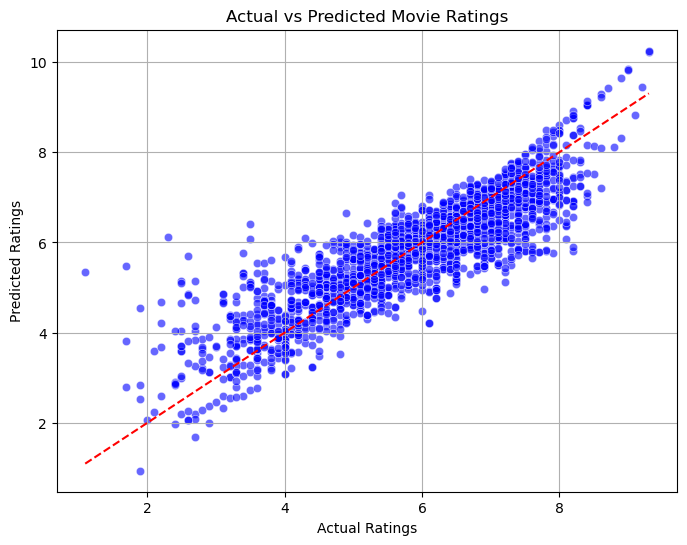

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')  # Use predicted values variable 'y_pred'
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Reference line (y=x)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Movie Ratings")
plt.grid(True)
plt.show()


<h2>Model Testing</h2>

In [19]:
sample = pd.DataFrame({
    'Year': [2019], 'Votes': [36], 'Duration': [111], 'Genre_mean_rating': [5.8],
    'Director_encoded': [4.5], 'Actor1_encoded': [5.3],
    'Actor2_encoded': [4.5], 'Actor3_encoded': [4.5]
})

In [20]:
predicted_rating = model.predict(sample)

In [22]:
print("\nPredicted Rating:", round(predicted_rating[0], 2))


Predicted Rating: 4.21
